# Sweep Calibrate

Sweep betas over 0.02 to 0.2 in steps of 0.01 and record the number of people per mode and average trip times
designed to improve the calibration of QUANT by taking into account number of people on each mode in addition
to fitting the average trip time

In [1]:
"""
Library code
"""
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import struct
import sys
import io
import time
import os
import struct
import time
import csv

#where the output file is written to
#outputdir = 'outputs/'

sweep_df = pd.read_csv(r"data\sweepcalibrate.csv")
#sweep_df = pd.read_csv(r"data\sweepcalibrate_2.csv")
#todo: add some error columns
print(sweep_df.head())
#beta_(road|bus|rail), CijObs_(road|bus|rail), Cij_(road|bus|rail), CBarObs_(road|bus|rail), CBarPred_(road|bus|rail)



   beta_road  beta_bus  beta_rail  CijObs_road  CijObs_bus  CijObs_rail  \
0       0.02      0.02       0.02   15823031.0   2051031.0    2186372.0   
1       0.02      0.02       0.03   15823031.0   2051031.0    2186372.0   
2       0.02      0.02       0.04   15823031.0   2051031.0    2186372.0   
3       0.02      0.02       0.05   15823031.0   2051031.0    2186372.0   
4       0.02      0.02       0.06   15823031.0   2051031.0    2186372.0   

       Cij_road       Cij_bus      Cij_rail  CBarObs_road  CBarObs_bus  \
0  1.075378e+07  2.569803e+06  6.736855e+06     12.456312    26.643277   
1  1.298635e+07  3.091315e+06  3.982765e+06     12.456312    26.643277   
2  1.412330e+07  3.358435e+06  2.578700e+06     12.456312    26.643277   
3  1.474716e+07  3.507107e+06  1.806165e+06     12.456312    26.643277   
4  1.512110e+07  3.597654e+06  1.341684e+06     12.456312    26.643277   

   CBarObs_rail  CBarPred_road  CBarPred_bus  CBarPred_rail  
0     30.629092      67.034587     89.5307

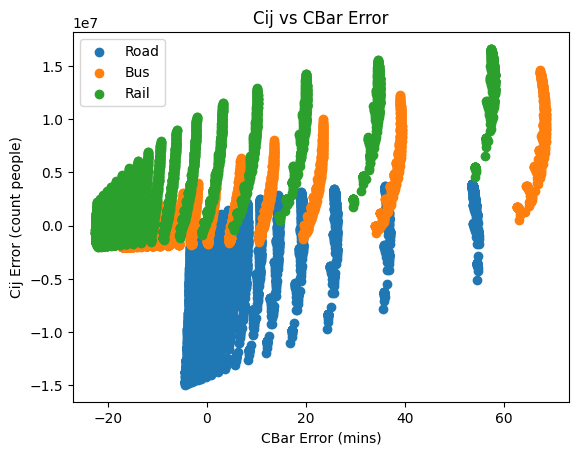

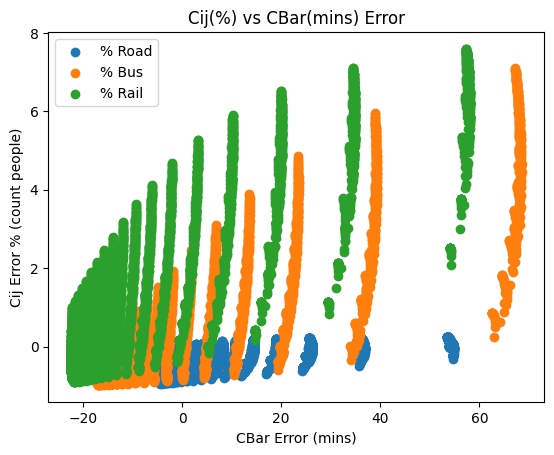

In [2]:
"""
do some plotting - individual error Cij vs error CBar by mode
"""
import numpy as np
import matplotlib.pyplot as plt

sweep_df['e_raw_Cij_road']=sweep_df['Cij_road']-sweep_df['CijObs_road']
sweep_df['e_raw_CBar_road']=sweep_df['CBarPred_road']-sweep_df['CBarObs_road']
sweep_df['e_pct_Cij_road']=sweep_df['e_raw_Cij_road']/sweep_df['CijObs_road']

sweep_df['e_raw_Cij_bus']=sweep_df['Cij_bus']-sweep_df['CijObs_bus']
sweep_df['e_raw_CBar_bus']=sweep_df['CBarPred_bus']-sweep_df['CBarObs_bus']
sweep_df['e_pct_Cij_bus']=sweep_df['e_raw_Cij_bus']/sweep_df['CijObs_bus']

sweep_df['e_raw_Cij_rail']=sweep_df['Cij_rail']-sweep_df['CijObs_rail']
sweep_df['e_raw_CBar_rail']=sweep_df['CBarPred_rail']-sweep_df['CBarObs_rail']
sweep_df['e_pct_Cij_rail']=sweep_df['e_raw_Cij_rail']/sweep_df['CijObs_rail']

plt.scatter(sweep_df['e_raw_CBar_road'],sweep_df['e_raw_Cij_road'],label='Road')
plt.scatter(sweep_df['e_raw_CBar_bus'],sweep_df['e_raw_Cij_bus'],label='Bus')
plt.scatter(sweep_df['e_raw_CBar_rail'],sweep_df['e_raw_Cij_rail'],label='Rail')
plt.xlabel('CBar Error (mins)')
plt.ylabel('Cij Error (count people)')
plt.title('Cij vs CBar Error')
plt.legend()

#new plot
plt.figure()
plt.scatter(sweep_df['e_raw_CBar_road'],sweep_df['e_pct_Cij_road'],label='% Road')
plt.scatter(sweep_df['e_raw_CBar_bus'],sweep_df['e_pct_Cij_bus'],label='% Bus')
plt.scatter(sweep_df['e_raw_CBar_rail'],sweep_df['e_pct_Cij_rail'],label='% Rail')
plt.xlabel('CBar Error (mins)')
plt.ylabel('Cij Error % (count people)')
plt.title('Cij(%) vs CBar(mins) Error')
plt.legend()
